In [1]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

In [2]:
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
from kszcnn.same_real_cnn_galaxy_overdensity import *

In [4]:
train_sets, test_sets = get_experiment_sets("same_real")
title = make_title("1P_0", input_type="overdensity", exp_type="same_real")

In [5]:
print("SET:", set_name)
print("HALO_FILE:", HALO_FILE)

SET: 1P_0
HALO_FILE: /home/sucharita/kszCNN/data/groups_090_1P_0.hdf5


In [6]:
np.random.seed(SEED)
torch.manual_seed(SEED)

In [7]:
# load halos + subhalos
pos, vel, mass, sub_pos, sub_mstar = \
    load_groups_and_subhalos(HALO_FILE)

# build galaxy overdensity field 
density_grid = build_galaxy_density_grid(
    sub_pos,
    sub_mstar,
    Ngrid=128,
    mstar_cut=1e8
)

# smooth 
density_grid = smooth_delta_field(density_grid, SMOOTH_SCALE)

Selected galaxies: 923


In [8]:
#  5. Dataset 
rng = np.random.RandomState(SEED)
full_ds = HaloDataset(density_grid, pos, vel, mass,
                      mass_cut=MASS_CUT, rng=rng)

#  split 
idxs = np.arange(len(full_ds))

train_idx, test_idx = train_test_split(
    idxs, test_size=0.2, random_state=SEED
)

train_idx, val_idx = train_test_split(
    train_idx, test_size=0.2, random_state=SEED
)

Number of halos above mass 1e11: 547


In [9]:
train_ds = Subset(full_ds, train_idx)
val_ds   = Subset(full_ds, val_idx)
test_ds  = Subset(full_ds, test_idx)

In [10]:
tr_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH)
te_loader  = DataLoader(test_ds, batch_size=BATCH)

In [11]:
#  9. Normalize velocity
y_train = np.array([full_ds[i][1] for i in train_idx])

y_mean = y_train.mean()
y_std  = y_train.std() + 1e-12

print("Velocity mean/std:", y_mean, y_std)

Velocity mean/std: 0.36430642 107.621216


In [12]:
#  6. Linear baseline 

vlin_grid = compute_vlin_from_delta(
    density_grid,   # full box
    R_smooth=SMOOTH_SCALE
)

#  get test positions 
test_pos = full_ds.pos[test_idx]
test_vz  = full_ds.vz[test_idx]

#  sample 
vlin_baseline = vlin_at_halos(
    vlin_grid,
    test_pos
)

# correlation
rho_vlin = pearsonr(test_vz, vlin_baseline)[0]

print("Linear theory correlation (δg):", rho_vlin)

Linear theory correlation (δg): 0.83614224


In [13]:
model = CNN().to(DEVICE)

In [14]:
train_model(
        model, tr_loader, val_loader, y_mean, y_std
    )

Epoch 1: Train=4.908e-01 | Val=6.260e-01
Epoch 2: Train=3.574e-01 | Val=3.981e-01
Epoch 3: Train=3.015e-01 | Val=3.866e-01
Epoch 4: Train=2.970e-01 | Val=4.058e-01
Epoch 5: Train=2.780e-01 | Val=3.828e-01
Epoch 6: Train=2.656e-01 | Val=3.708e-01
Epoch 7: Train=2.480e-01 | Val=3.754e-01
Epoch 8: Train=2.432e-01 | Val=4.639e-01
Epoch 9: Train=2.400e-01 | Val=3.608e-01
Epoch 10: Train=2.295e-01 | Val=3.567e-01
Epoch 11: Train=2.333e-01 | Val=3.581e-01
Epoch 12: Train=2.323e-01 | Val=4.211e-01
Epoch 13: Train=2.203e-01 | Val=3.685e-01
Epoch 14: Train=2.247e-01 | Val=3.514e-01
Epoch 15: Train=2.095e-01 | Val=3.526e-01
Epoch 16: Train=2.147e-01 | Val=3.680e-01
Epoch 17: Train=2.232e-01 | Val=3.812e-01
Epoch 18: Train=2.143e-01 | Val=3.399e-01
Epoch 19: Train=2.148e-01 | Val=3.489e-01
Epoch 20: Train=2.037e-01 | Val=3.529e-01
Epoch 21: Train=1.932e-01 | Val=3.307e-01
Epoch 22: Train=1.973e-01 | Val=3.336e-01
Epoch 23: Train=2.037e-01 | Val=3.574e-01
Epoch 24: Train=1.863e-01 | Val=3.525e-01
E

CNN(
  (conv): Sequential(
    (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): GroupNorm(8, 64, eps=1e-05, affine=True)
    (6): ReLU()
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): GroupNorm(8, 128, eps=1e-05, affine=True)
    (10): ReLU()
    (11): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool3d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

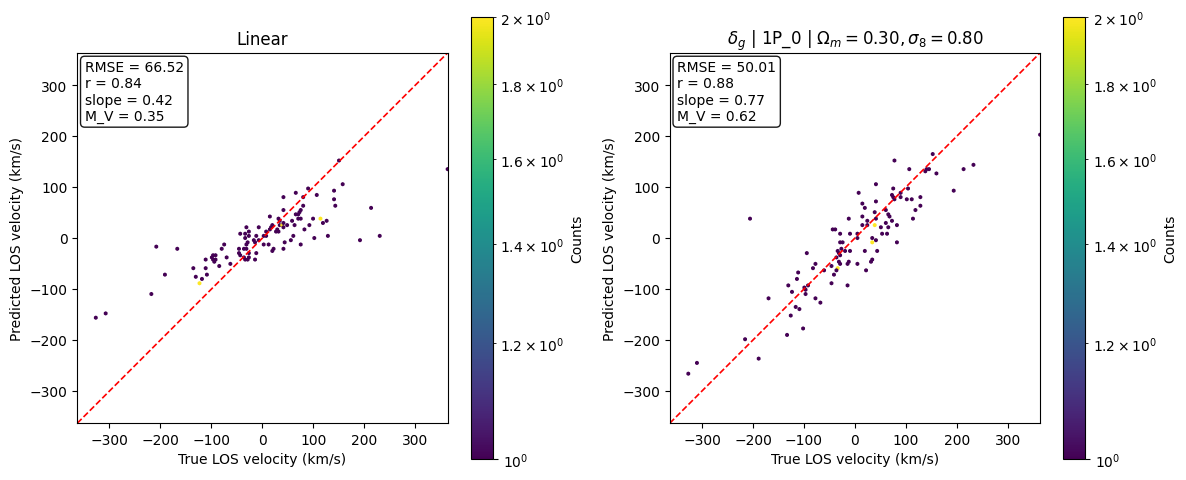

In [15]:
evaluate_model(
        model, te_loader, test_ds,
        y_mean, y_std,
        vlin_baseline, rho_vlin
    )